# 1. 使用映射变换实现图像区域内容变换

- 图像内容跟换

- 引入模块

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

- 读取替换图像

In [12]:
img_src = cv2.imread("imgs/scene.jpg", cv2.IMREAD_COLOR_RGB)
h, w, _ = img_src.shape

- 取得四个坐标

In [13]:

pst_src = np.array(
    [
        [0,         0], [w - 1, 0],
        [w - 1, h - 1], [0, h - 1]
     ], 
    dtype=float
)

- 读取被替换内容的图像

In [14]:
img_dst = cv2.imread("imgs/pukou.jpg", cv2.IMREAD_COLOR_RGB)

- 使用鼠标获取被替换图像中的内容区域

In [15]:
# 鼠标事件处理函数
def mouse_handler(event, x, y, flags, data):
    if event ==cv2.EVENT_LBUTTONDOWN:
        # 在替换图像中画个圆圈标记这个点
        cv2.circle(data['im'], (x, y), 5, (0, 0, 255), 5)
        # 重新显示图像
        # cv2.namedWindow("Image", 0)
        cv2.imshow("Image",data['im'])
        # 如果大于等于4个点，标记的数据不存储，并且不做人格处理
        if len(data['points']) < 4:
            data['points'].append([x, y])
            
        

In [16]:
# 存放被替换内容的四个区域（两个字段：im存放图像，points存放四个点）
data = {}  # 使用参数返回数据
data['im'] = img_dst.copy() # 传递给鼠标处理事件的图像使用克隆，防止原图被修改
data['points'] = []   # 存储标记的4个点

# 显示窗体，提供鼠标标记互动。
cv2.namedWindow("Image", 0)
cv2.imshow('Image', img_dst)
#请注意你标记点的数据，是顺时针，需要与替换内容的4个点的方位保持一致。
cv2.setMouseCallback("Image", mouse_handler, data)
# 按键结束被替换区域的标记。
cv2.waitKey(0)

print(data["points"])

[[3059, 1028], [3651, 732], [3651, 1170], [3045, 1235]]


- 计算透视图变换矩阵

In [7]:
#竖直方向堆叠起来
four_points = np.vstack(data['points']).astype(float)

# 使用源区域与目标区域两个数据计算透视图变换矩阵
h, status = cv2.findHomography(pst_src, four_points)  # 这个有两种方法
print(h)
print(status)

[[-4.38226626e-01  1.34070729e-01  2.92400000e+03]
 [-3.26846734e-01  2.20312819e-01  1.06000000e+03]
 [-2.22042840e-04  3.82731170e-05  1.00000000e+00]]
[[1]
 [1]
 [1]
 [1]]


- 进行透视图变换得到与替换区域一样大小的图像。

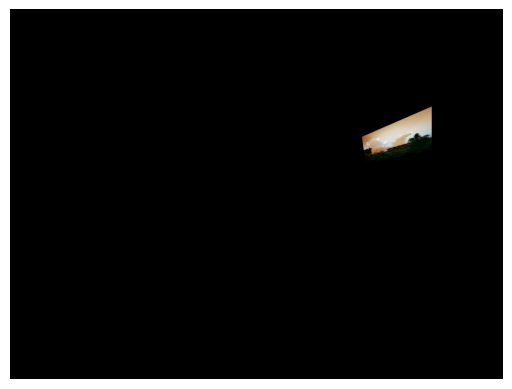

In [8]:
im_temp = cv2.warpPerspective(img_src, h,  (img_dst.shape[1], img_dst.shape[0]))
plt.imshow(im_temp)
plt.axis("off")
plt.show()

- 对被替换的区域进行填充

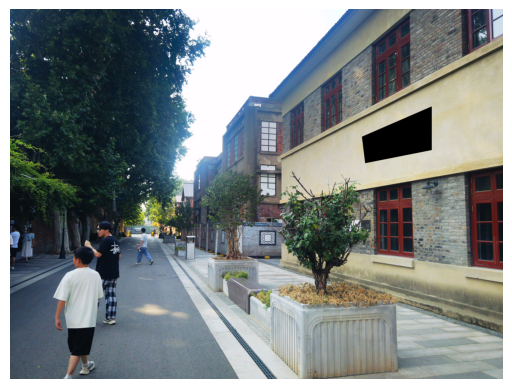

In [9]:
cv2.fillConvexPoly(img_dst, four_points.astype(int), 0, 16)
plt.imshow(img_dst)
plt.axis("off")
plt.show()

- 两个图像叠加，得到替换结果

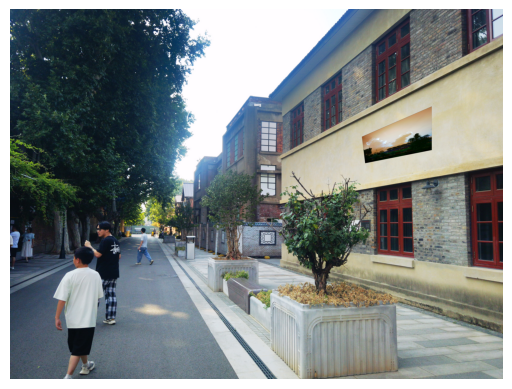

In [10]:
img_dst = img_dst + im_temp
plt.imshow(img_dst)
plt.axis("off")
plt.show()

----

# 2. 使用透视图变换实现图像区域内容替换

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_src = cv2.imread("imgs/scene.jpg", cv2.IMREAD_COLOR_BGR)
h, w, _ = img_src.shape


pst_src = np.array(
    [
        [0,         0], [w - 1, 0],
        [w - 1, h - 1], [0, h - 1]
    ], 
    dtype=np.float32
)

img_dst = cv2.imread("imgs/pukou.jpg", cv2.IMREAD_COLOR_BGR)

# 鼠标事件处理函数
def mouse_handler(event, x, y, flags, data):
    if event ==cv2.EVENT_LBUTTONDOWN:
        # 在替换图像中画个圆圈标记这个点
        cv2.circle(data['im'], (x, y), 5, (0, 0, 255), 5)
        # 重新显示图像
        # cv2.namedWindow("Image", 0)
        cv2.imshow("Image",data['im'])
        # 如果大于等于4个点，标记的数据不存储，并且不做人格处理
        if len(data['points']) < 4:
            data['points'].append([x, y])
            
# 存放被替换内容的四个区域（两个字段：im存放图像，points存放四个点）
data = {}  # 使用参数返回数据
data['im'] = img_dst.copy() # 传递给鼠标处理事件的图像使用克隆，防止原图被修改
data['points'] = []   # 存储标记的4个点

# 显示窗体，提供鼠标标记互动。
cv2.namedWindow("Image", 0)
cv2.resizeWindow("Image", 400, 300)
cv2.imshow('Image', img_dst)
#请注意你标记点的数据，是顺时针，需要与替换内容的4个点的方位保持一致。
cv2.setMouseCallback("Image", mouse_handler, data)
# 按键结束被替换区域的标记。
cv2.waitKey(0)
cv2.destroyAllWindows()

print(data["points"])
#竖直方向堆叠起来
four_points = np.vstack(data['points']).astype(np.float32)

# 使用源区域与目标区域两个数据计算透视图变换矩阵
# h, status = cv2.findHomography(pst_src, four_points)  # 这个有两种方法
print()
h = cv2.getPerspectiveTransform(pst_src, four_points)

print(h)
im_temp = cv2.warpPerspective(img_src, h,  (img_dst.shape[1], img_dst.shape[0]))

cv2.fillConvexPoly(img_dst, four_points.astype(int), 0, 16)

img_dst = img_dst + im_temp
cv2.namedWindow("Image", 0)
cv2.imshow('Image', img_dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

[[3062, 1004], [3082, 1321], [3697, 1157], [3686, 666]]

[[ 4.94157058e-02 -5.13750248e-01  3.06200000e+03]
 [ 2.02076429e-01 -4.45523156e-01  1.00400000e+03]
 [ 1.22276121e-05 -2.71842962e-04  1.00000000e+00]]


- 代码说明：
    - 在getPerspectiveTransform中，参数必须是shape=(4，2)的numpy.ndarray，元素类型必须是numpy.float32。